In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pq.read_table("../ori_data/clean_data_r28n4.parquet")
df = df.to_pandas(ignore_metadata=True)

In [142]:
df.shape

(152347, 13)

In [100]:
df.head()

,timestamp,node_power_usage,node_memory_Active_bytes,node_ambient_temp,node_load1,node_memory_Percpu_bytes,node_procs_blocked,node_memory_MemFree_bytes,node_procs_running,nvidia_gpu_memory_used_bytes_sum,nvidia_gpu_temperature_celsius_mean,nvidia_gpu_fanspeed_percent_mean,nvidia_gpu_power_usage_milliwatts_mean,nvidia_gpu_duty_cycle_mean
0,2022-08-25 10:27:00,1080.0,5.774050e+10,25.0,5.84,52166700.0,1.0,1.216100e+11,23.0,1.949067e+10,56.75,49.25,137841.25,41.75
1,2022-08-25 10:27:30,1080.0,5.790800e+10,25.0,6.10,52166700.0,0.0,1.214570e+11,9.0,1.949067e+10,56.75,49.25,129485.75,44.25
2,2022-08-25 10:28:00,1080.0,5.802380e+10,25.0,5.82,52166700.0,0.0,1.215890e+11,16.0,1.949067e+10,56.50,49.25,152222.50,41.00
3,2022-08-25 10:28:30,960.0,5.750030e+10,25.0,7.88,52166700.0,1.0,1.220990e+11,16.0,1.949067e+10,55.75,49.25,109400.25,35.00
4,2022-08-25 10:29:00,960.0,5.743630e+10,25.0,7.06,52166700.0,0.0,1.229560e+11,19.0,1.949067e+10,56.25,49.00,137856.50,42.25


|字段|含义|单位|说明|
|---|---|---|---|
|node_power_usage|节点功率使用量|瓦特（W）|表示该节点当前消耗的总电功率，通常包括 CPU、内存、GPU、风扇等设备的功耗总和。|
|node_memory_Active_bytes|活跃内存字节数字节|（Bytes）|操作系统认为“正在被使用”的内存量（活跃页），即不能被回收的内存部分。|
|node_ambient_temp|节点环境温度|摄氏度（°C）|监测节点所在机架或机房周围的空气温度，用于评估散热与能效。|
|node_load1|1分钟平均负载|无单位|Linux系统1分钟内的平均运行队列长度，反映 CPU 忙碌程度（>CPU核数 时表示过载）。|
|node_memory_Percpu_bytes|每个 CPU 的内存分配量|字节（Bytes）|表示系统为各 CPU 分配或使用的内存量，用于衡量 CPU 级别的内存占用。|
|node_procs_blocked|阻塞进程数|个（count）|当前处于等待 I/O 操作或资源锁的进程数量。值大可能意味着磁盘或网络瓶颈。|
|node_memory_MemFree_bytes|可用空闲内存|字节（Bytes）|系统中未被使用的物理内存，可被进程直接分配。反映内存充裕程度。|
|node_procs_running|正在运行的进程数|个（count）|	当前处于“运行态”的进程数量，即占用 CPU 的活跃进程数。|
|nvidia_gpu_memory_used_bytes_sum	| GPU 显存总使用量	| 字节（Bytes）|	当前节点上所有 GPU 已使用的显存总和，用于评估 GPU 任务的显存占用。|
|nvidia_gpu_temperature_celsius_mean|	GPU 平均温度	|摄氏度（°C）	|节点上所有 GPU 温度的平均值。温度过高可能会触发功率限制或性能下降。|
|nvidia_gpu_fanspeed_percent_mean	|GPU 平均风扇转速	|百分比（%）	|节点上 GPU 风扇转速的平均百分比（相对于最大转速）。反映散热强度。|
|nvidia_gpu_power_usage_milliwatts_mean|	GPU 平均功率使用量	|毫瓦（mW）|	节点上 GPU 当前消耗功率的平均值。可换算为瓦特（1 W = 1000 mW）。|
|nvidia_gpu_duty_cycle_mean|GPU 平均负载占比|百分比（%）|GPU 计算核心的平均占用率（类似于 GPU 利用率），反映任务繁忙程度|


1. 单位转换，比如字节单位，太小了。
2. 所有字段可以先保存，对比去掉大多数字段后的表现。

**Task Formulation**:
1. 功耗回归建模（静态）。由当前其他变量估计当前功耗；
2. 功耗时序预测（动态）。未来窗口预测，根据历史窗口内的变量，预测未来系统的一段时间功耗。

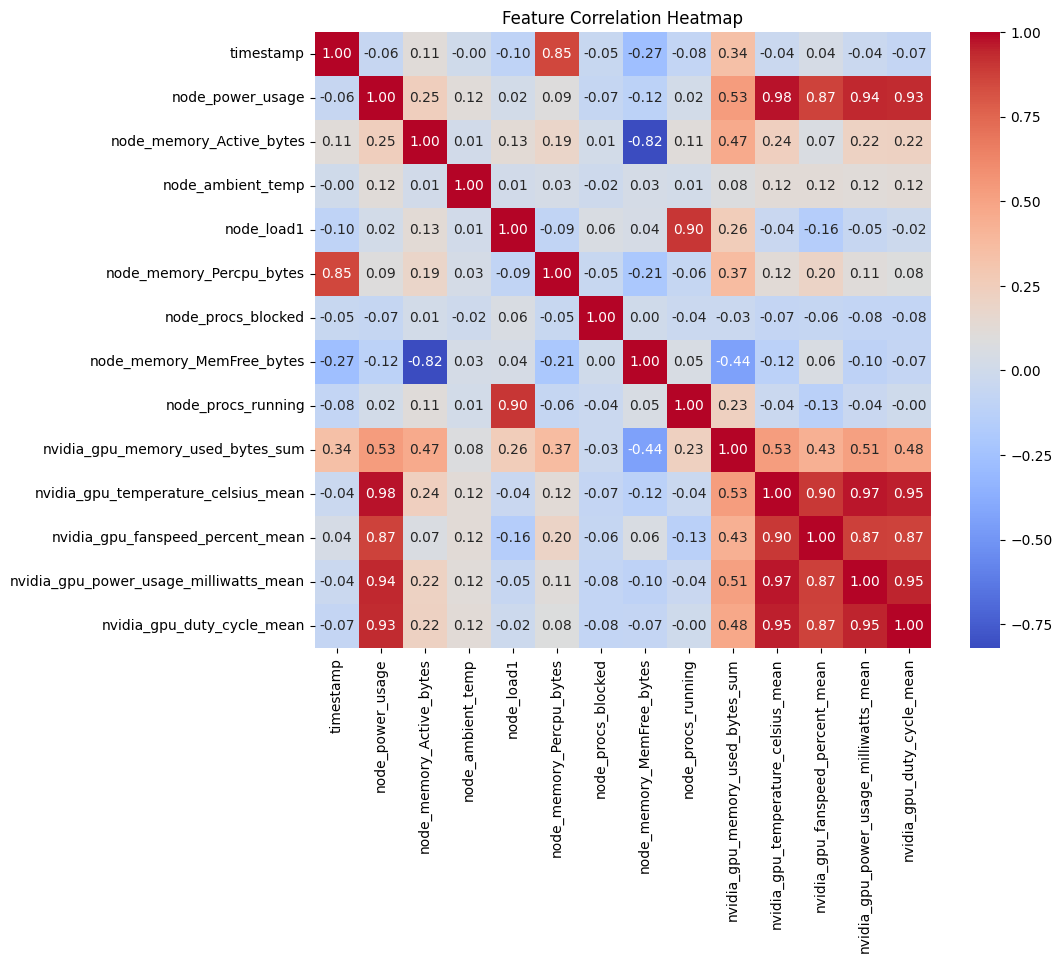

In [7]:
corr = df.corr()

# 2. 绘制热力图
plt.figure(figsize=(10, 8))
sns.heatmap(corr, 
            annot=True,        # 显示数值
            fmt=".2f",         # 小数位数
            cmap="coolwarm",   # 颜色风格
            square=True)       # 方形格
plt.title("Feature Correlation Heatmap")
plt.show()

功耗和GPU利用率、GPU平均功耗、GPU风扇速度以及GPU温度最为相关。

/data3/maminbo/.conda/envs/metro/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25955 (\N{CJK UNIFIED IDEOGRAPH-6563}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data3/maminbo/.conda/envs/metro/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data3/maminbo/.conda/envs/metro/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data3/maminbo/.conda/envs/metro/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data3/maminbo/.conda/envs/metro/lib/python3.11/site-packages/IPython/core/pylabtools.py

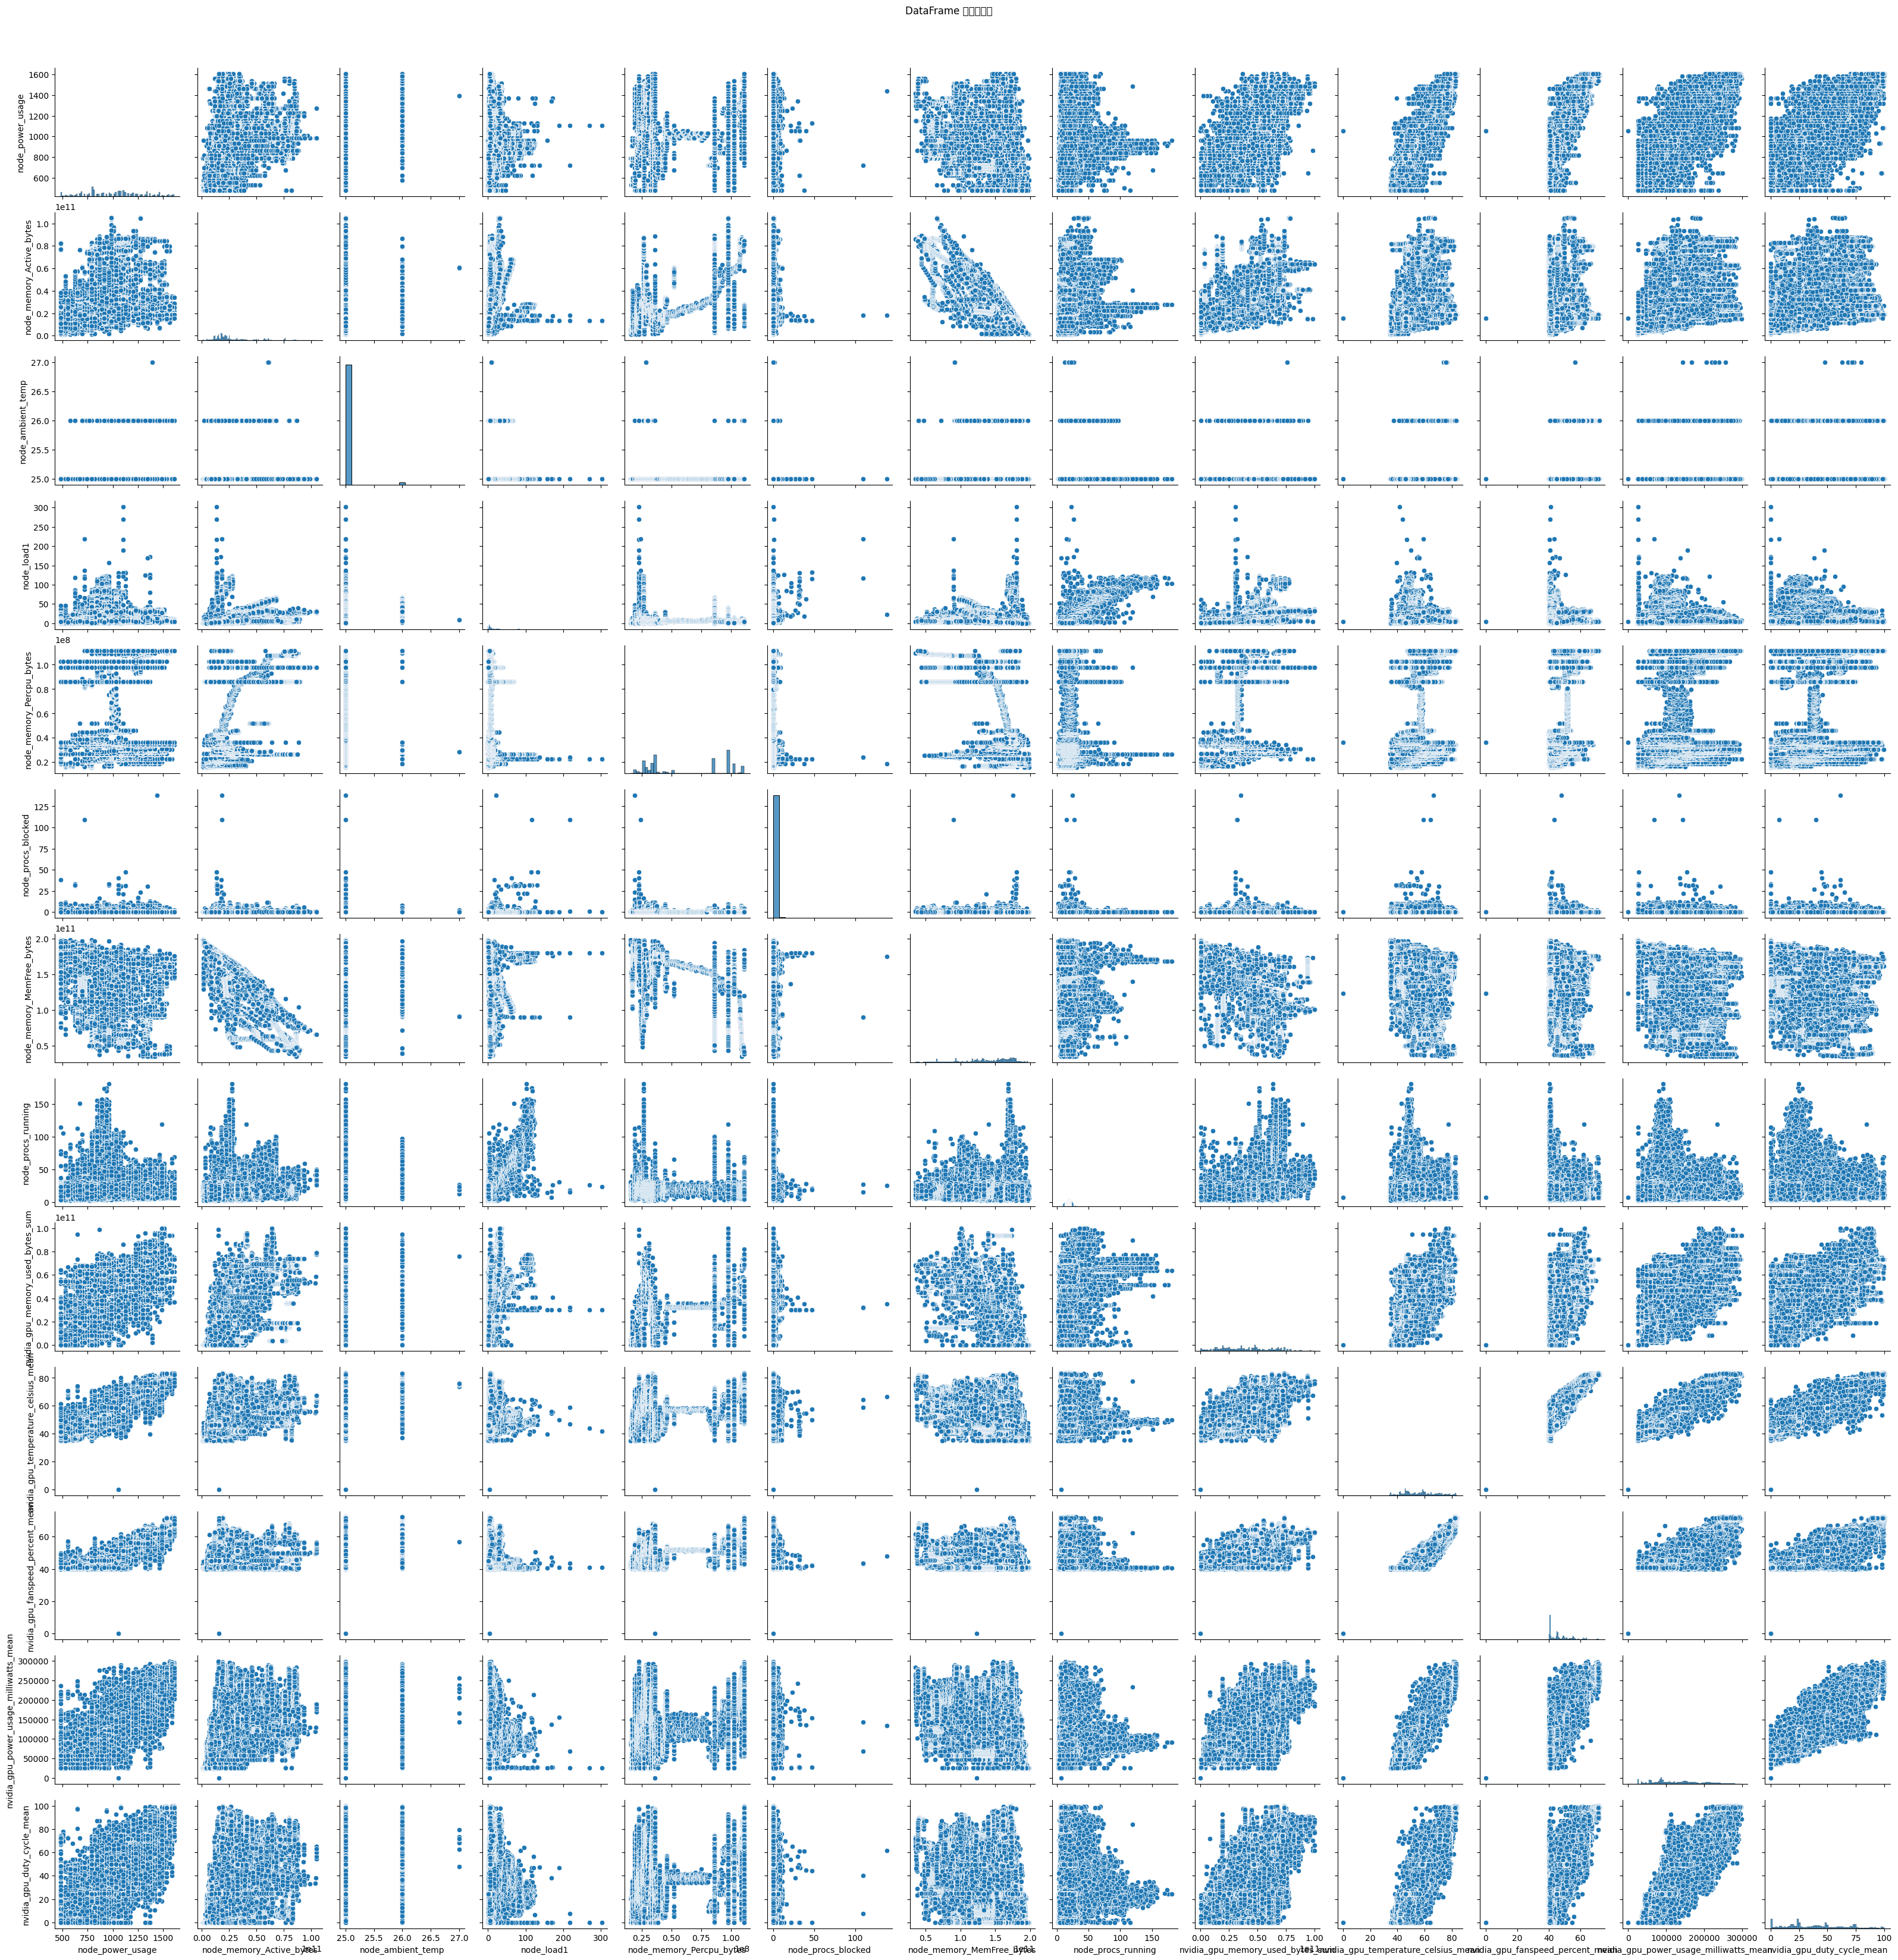

In [8]:
sns.pairplot(df, diag_kind='hist', corner=False)  # corner=True只画上三角，避免重复
plt.suptitle("DataFrame 散点图矩阵", y=1.02)
plt.show()

In [101]:
# 填补缺失值
df.interpolate(method='linear', inplace=True)
print(df.isnull().sum())

timestamp                                 0
node_power_usage                          0
node_memory_Active_bytes                  0
node_ambient_temp                         0
node_load1                                0
node_memory_Percpu_bytes                  0
node_procs_blocked                        0
node_memory_MemFree_bytes                 0
node_procs_running                        0
nvidia_gpu_memory_used_bytes_sum          0
nvidia_gpu_temperature_celsius_mean       0
nvidia_gpu_fanspeed_percent_mean          0
nvidia_gpu_power_usage_milliwatts_mean    0
nvidia_gpu_duty_cycle_mean                0
dtype: int64


In [102]:
# setting timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')
df = df.set_index('timestamp')

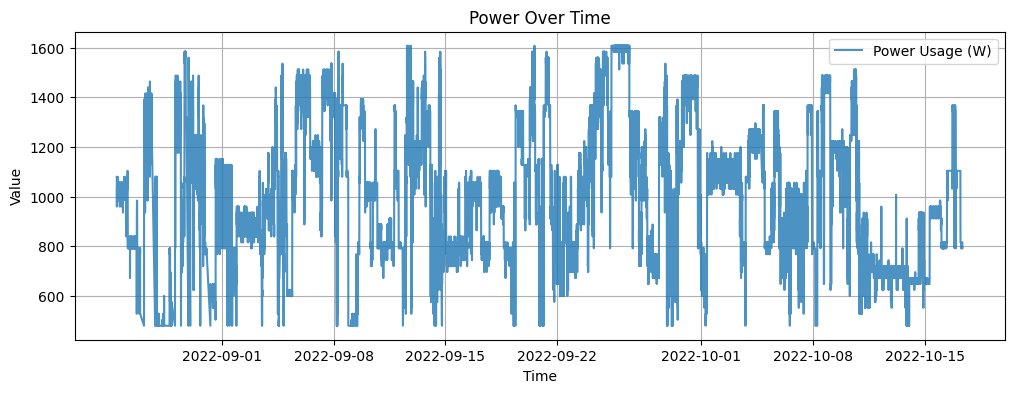

In [5]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['node_power_usage'], label='Power Usage (W)', alpha=0.8)
plt.title("Power Over Time")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

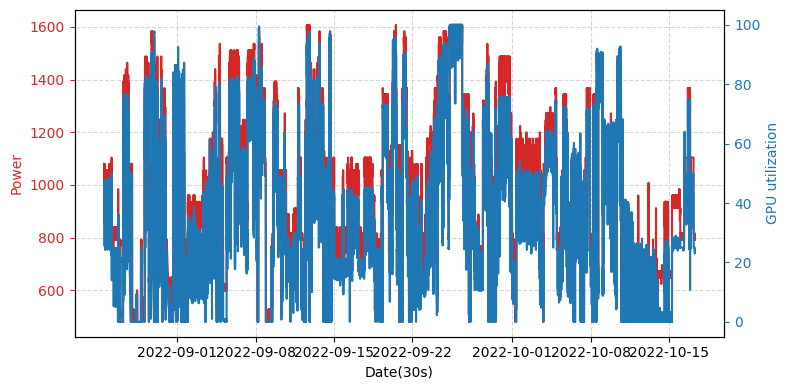

In [8]:
fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()  # 第二个Y轴

ln1 = ax1.plot(df.index, df['node_power_usage'], color='tab:red', label='power')
ln2 = ax2.plot(df.index, df['nvidia_gpu_duty_cycle_mean'], color='tab:blue', label='GPU Utilization')

# 设置坐标轴与标题
ax1.set_xlabel('Date(30s)', fontsize=10)
ax1.set_ylabel('Power', fontsize=10, color='tab:red')
ax2.set_ylabel('GPU utilization', fontsize=10, color='tab:blue')

# 设置颜色
ax1.tick_params(axis='y', colors='tab:red')
ax2.tick_params(axis='y', colors='tab:blue')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_107841/1978852078.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  power = df['node_power_usage'].resample('1H').mean()
/tmp/ipykernel_107841/1978852078.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  gpu =  df['nvidia_gpu_duty_cycle_mean'].resample('1H').mean()


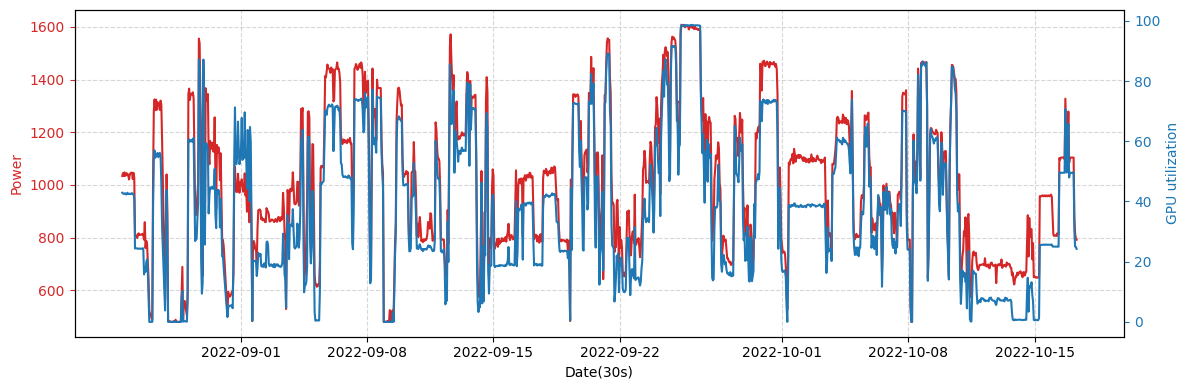

In [14]:
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()  # 第二个Y轴
power = df['node_power_usage'].resample('1H').mean()
gpu =  df['nvidia_gpu_duty_cycle_mean'].resample('1H').mean()

ln1 = ax1.plot(power.index, power, color='tab:red', label='power')
ln2 = ax2.plot(gpu.index, gpu, color='tab:blue', label='GPU Utilization')

# 设置坐标轴与标题
ax1.set_xlabel('Date(30s)', fontsize=10)
ax1.set_ylabel('Power', fontsize=10, color='tab:red')
ax2.set_ylabel('GPU utilization', fontsize=10, color='tab:blue')

# 设置颜色
ax1.tick_params(axis='y', colors='tab:red')
ax2.tick_params(axis='y', colors='tab:blue')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

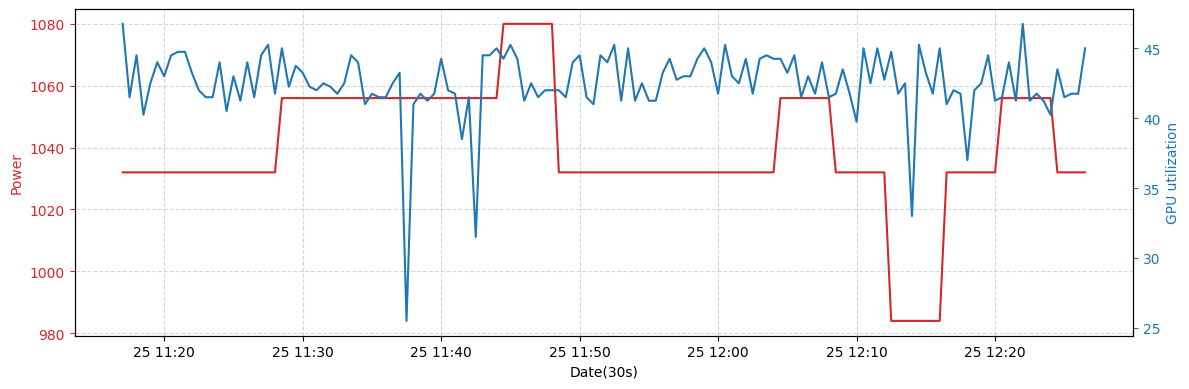

In [141]:
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()  # 第二个Y轴
power = df['node_power_usage'][100:240]
gpu =  df['nvidia_gpu_duty_cycle_mean'][100:240]

ln1 = ax1.plot(power.index, power, color='tab:red', label='power')
ln2 = ax2.plot(gpu.index, gpu, color='tab:blue', label='GPU Utilization')

# 设置坐标轴与标题
ax1.set_xlabel('Date(30s)', fontsize=10)
ax1.set_ylabel('Power', fontsize=10, color='tab:red')
ax2.set_ylabel('GPU utilization', fontsize=10, color='tab:blue')

# 设置颜色
ax1.tick_params(axis='y', colors='tab:red')
ax2.tick_params(axis='y', colors='tab:blue')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

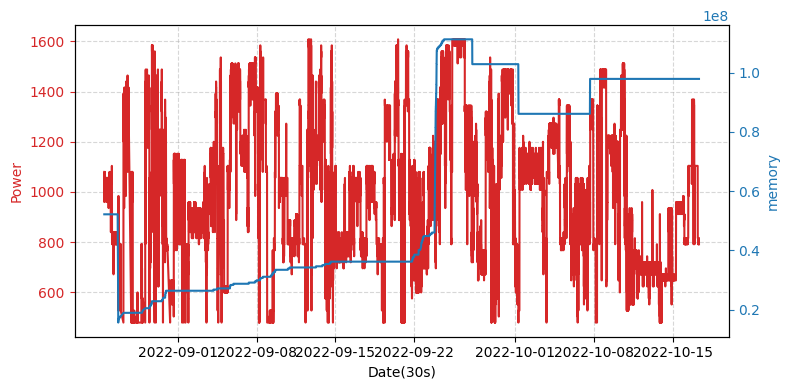

In [10]:
fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()  # 第二个Y轴

ln1 = ax1.plot(df.index, df['node_power_usage'], color='tab:red', label='power')
ln2 = ax2.plot(df.index, df['node_memory_Percpu_bytes'], color='tab:blue', label='memory')

# 设置坐标轴与标题
ax1.set_xlabel('Date(30s)', fontsize=10)
ax1.set_ylabel('Power', fontsize=10, color='tab:red')
ax2.set_ylabel('memory', fontsize=10, color='tab:blue')

# 设置颜色
ax1.tick_params(axis='y', colors='tab:red')
ax2.tick_params(axis='y', colors='tab:blue')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

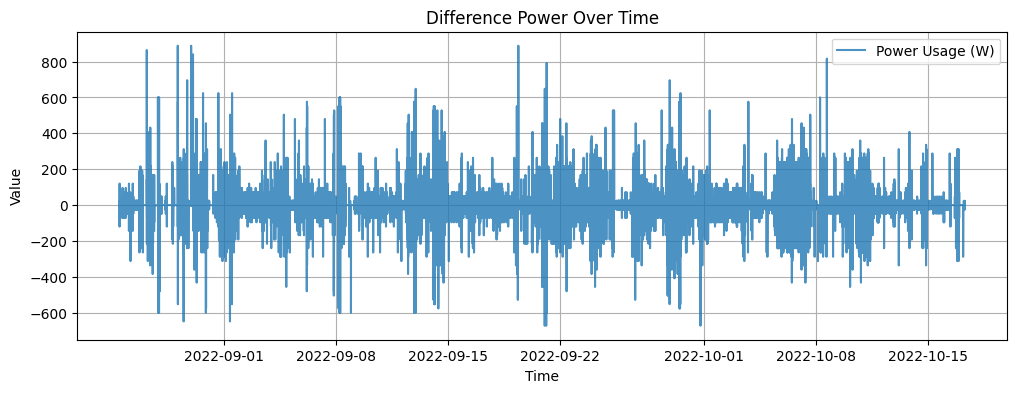

In [7]:
df['power_diff'] = df['node_power_usage'].diff()

plt.figure(figsize=(12, 4))
plt.plot(df.index, df['power_diff'], label='Power Usage (W)', alpha=0.8)
plt.title("Difference Power Over Time")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['power_diff'].iloc[1:].values)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -55.44414530138878
p-value: 0.0


差分后的数据是平稳的，还需进一步论证是否具有自相关结构

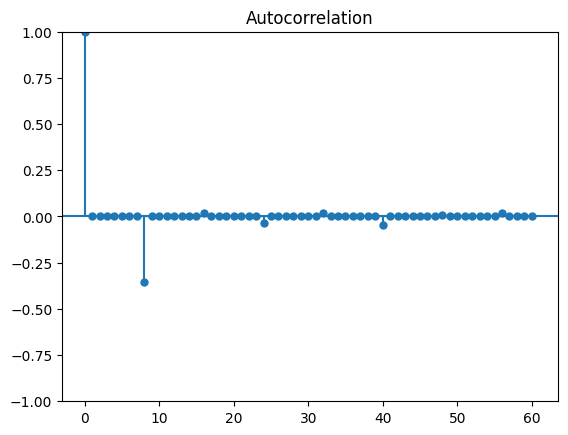

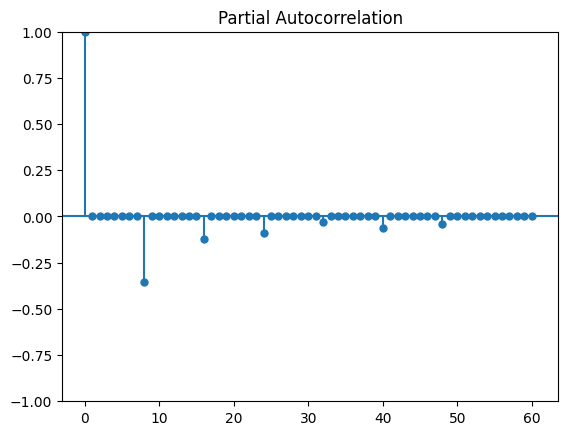

          lb_stat  lb_pvalue
10   19199.061730        0.0
120  20383.370356        0.0


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt

plot_acf(df['power_diff'].iloc[1:].values, lags=60)
plot_pacf(df['power_diff'].iloc[1:].values, lags=60)
plt.show()

lb_test = acorr_ljungbox(df['power_diff'].iloc[1:].values, lags=[10, 120], return_df=True)
print(lb_test)

从自相关结构图上来看，仅在滞后8附近有个负相关性。lb_stat数值越大，说明序列与白噪声差异越显著，非常强烈地拒绝白噪声假设。二者相互矛盾，难以判断。

In [6]:
avg_power = df['node_power_usage'].mean()
peak_power = df['node_power_usage'].max()
power_variation = df['node_power_usage'].std()
peak_to_avg_ratio = peak_power / avg_power

print("\n=== 功率特性指标 ===")
print(f"平均功率: {avg_power:.2f} W")
print(f"峰值功率: {peak_power:.2f} W")
print(f"功率标准差: {power_variation:.2f} W")
print(f"峰均比 (Peak-to-Average Ratio): {peak_to_avg_ratio:.2f}")


=== 功率特性指标 ===
平均功率: 1001.86 W
峰值功率: 1608.00 W
功率标准差: 285.85 W
峰均比 (Peak-to-Average Ratio): 1.61


In [12]:
avg_power_GPU = df['nvidia_gpu_power_usage_milliwatts_mean'].mean()
peak_power_GPU = df['nvidia_gpu_power_usage_milliwatts_mean'].max()
power_variation_GPU = df['nvidia_gpu_power_usage_milliwatts_mean'].std()
peak_to_avg_ratio_GPU = peak_power_GPU / avg_power_GPU

print("\n=== 功率特性指标 ===")
print(f"平均功率: {avg_power_GPU/1000:.2f} W")
print(f"峰值功率: {peak_power_GPU/1000:.2f} W")
print(f"功率标准差: {power_variation_GPU/1000:.2f} W")
print(f"峰均比 (Peak-to-Average Ratio): {peak_to_avg_ratio_GPU:.2f}")


=== 功率特性指标 ===
平均功率: 128.84 W
峰值功率: 298.42 W
功率标准差: 64.32 W
峰均比 (Peak-to-Average Ratio): 2.32


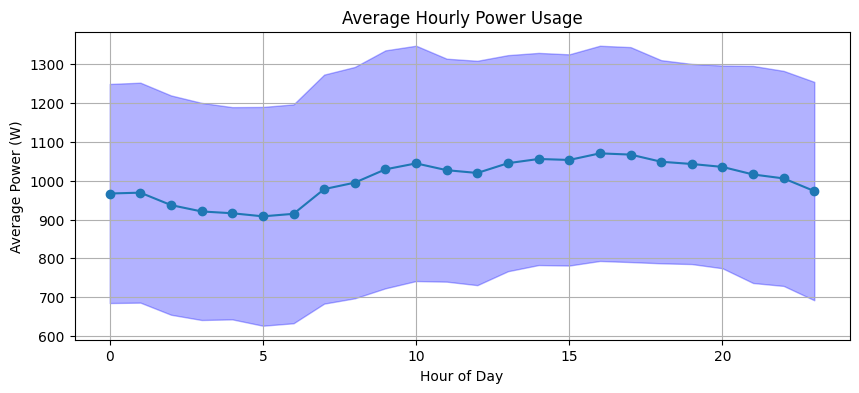

In [ ]:
df['hour'] = df.index.hour
hourly_stats = df.groupby('hour')['node_power_usage'].mean()
hourly_std = df.groupby('hour')['node_power_usage'].std()

plt.figure(figsize=(10, 4))
plt.plot(hourly_stats.index, hourly_stats.values, marker='o')
plt.fill_between(
    hourly_stats.index,
    hourly_stats - hourly_std,
    hourly_stats + hourly_std,
    color='blue',
    alpha=0.3,
    label='Std Dev'
)
plt.title('Average Hourly Power Usage')
plt.xlabel('Hour of Day')
plt.ylabel('Average Power (W)')
plt.grid(True)
plt.show()

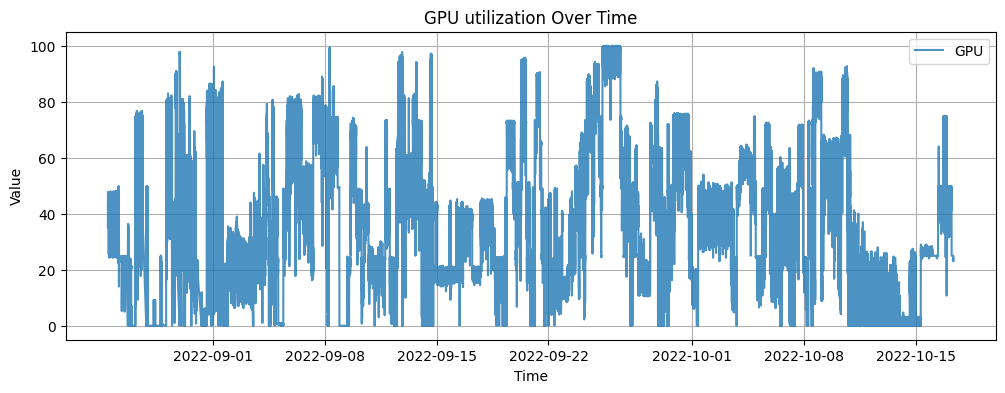

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['nvidia_gpu_duty_cycle_mean'], label='GPU', alpha=0.8)
plt.title("GPU utilization Over Time")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_4097510/2880272302.py:3: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  'minute': df['node_power_usage'].resample('1T').mean(),
/tmp/ipykernel_4097510/2880272302.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'hour': df['node_power_usage'].resample('1H').mean(),


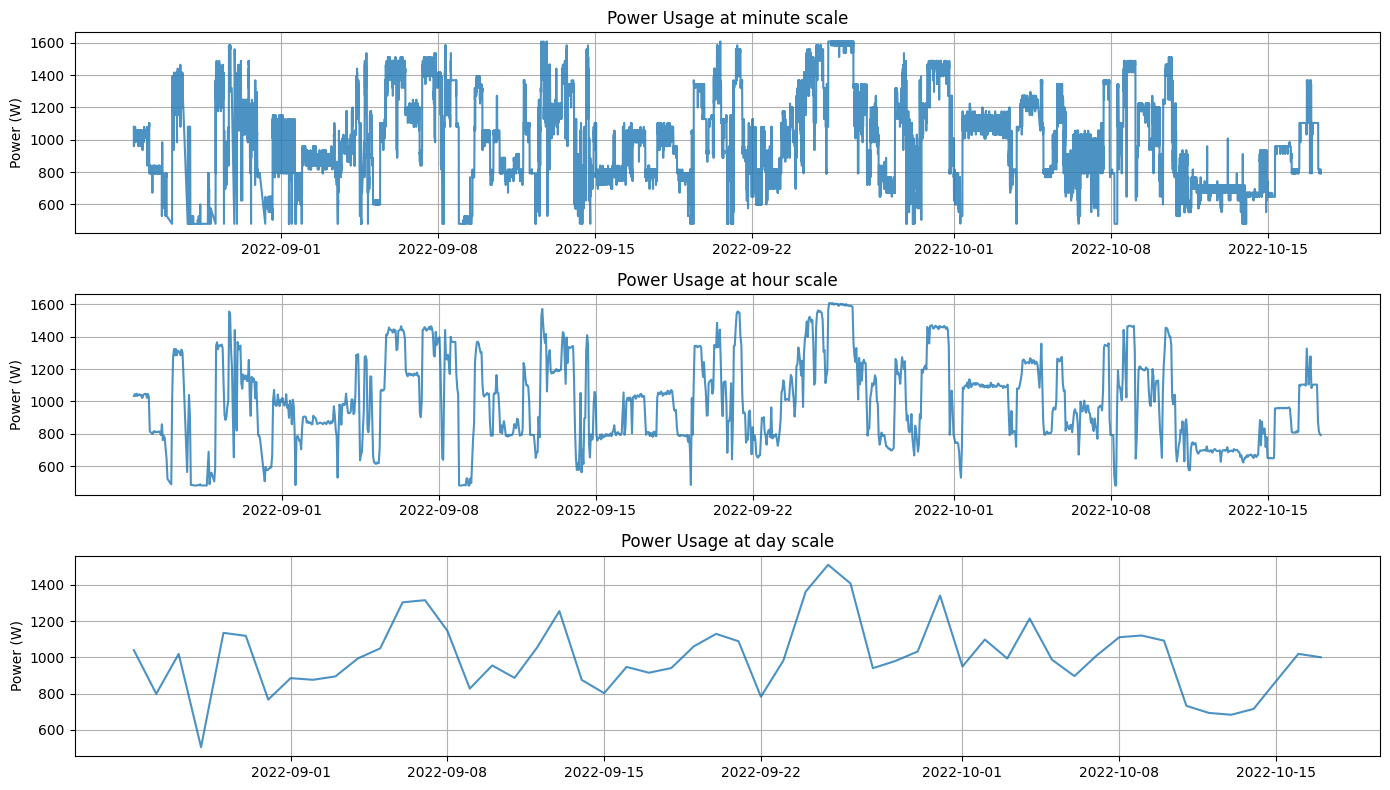

In [13]:
# 分析多时间尺度特性
scales = {
    'minute': df['node_power_usage'].resample('1T').mean(),
    'hour': df['node_power_usage'].resample('1H').mean(),
    'day': df['node_power_usage'].resample('1D').mean()
}

plt.figure(figsize=(14, 8))
for i, (label, series) in enumerate(scales.items(), start=1):
    plt.subplot(3, 1, i)
    plt.plot(series.index, series.values, label=f'{label} scale', alpha=0.8)
    plt.title(f'Power Usage at {label} scale')
    plt.ylabel('Power (W)')
    plt.grid(True)
    if i == 4:
        plt.xlabel('Time')
plt.tight_layout()
plt.show()

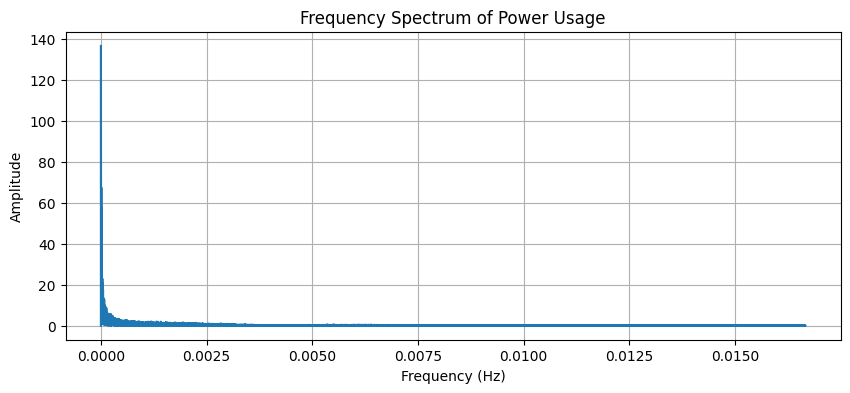

In [14]:
# 多时间尺度频谱分析

from scipy.fft import fft, fftfreq

N = len(df['node_power_usage'])
T = (df.index[1] - df.index[0]).total_seconds()
yf = fft(df['node_power_usage'] - df['node_power_usage'].mean())
xf = fftfreq(N, T)[:N//2]

plt.figure(figsize=(10, 4))
plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.title('Frequency Spectrum of Power Usage')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

<Axes: xlabel='timestamp'>

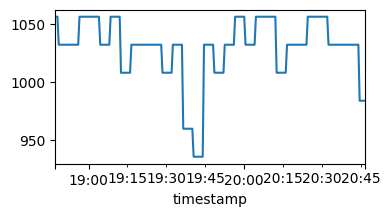

In [18]:
i = 1000
plt.figure(figsize=(4, 2))
df['node_power_usage'].iloc[i:i+240].plot()

/tmp/ipykernel_574461/2984329548.py:3: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df['node_power_usage'].iloc[i:i+240].resample('10T').mean().plot()


<Axes: xlabel='timestamp'>

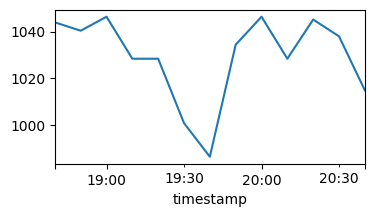

In [25]:
i = 1000
plt.figure(figsize=(4, 2))
df['node_power_usage'].iloc[i:i+240].resample('10T').mean().plot()

频谱图未发现明显周期

作业级能耗、利用率行为模式识别

In [26]:
job_df = pq.read_table("../ori_data/job_r28n4.parquet")
job_df = job_df.to_pandas(ignore_metadata=True)
job_df['submit_date'] = pd.to_datetime(job_df['submit_date'])
job_df['start_date'] = pd.to_datetime(job_df['start_date'])
job_df['end_date'] = pd.to_datetime(job_df['end_date'])

相似负载作业的分组

In [ ]:
aligned_records = []

for _, job in job_df.iterrows():
    job_metrics = df[
        (df.index >= job['start_date']) &
        (df.index <= job['end_date'])
    ]
    if not job_metrics.empty:
        _job = {
            'job_id': job['id'],
            'duration_sec': (job['end_date'] - job['start_date']).total_seconds(),
            'power_mean': job_metrics['node_power_usage'].mean(),
            'power_std': job_metrics['node_power_usage'].std(),
            'max': job_metrics['node_power_usage'].max(),
            'min': job_metrics['node_power_usage'].min(),
            "range": job_metrics['node_power_usage'].max() - job_metrics['node_power_usage'].min(),
            "skew_p": job_metrics['node_power_usage'].skew(),
            "kurt_p": job_metrics['node_power_usage'].kurt()
        }
        aligned_records.append(_job)

job_level_df = pd.DataFrame(aligned_records)

    job_id  duration_sec   power_mean   power_std     max    min  range  \
0  1919687      360328.0   942.193999  116.098346  1104.0  672.0  432.0   
1  1917196      295649.0  1040.093591   26.074690  1104.0  840.0  264.0   
2  1920248         263.0   762.666667   88.000000   792.0  528.0  264.0   
3  1920360        2411.0   900.300000  148.535841   984.0  528.0  456.0   
4  1920257         294.0   816.000000  101.192885   912.0  720.0  192.0   

     skew_p     kurt_p  
0 -0.259775  -1.810174  
1 -2.760418  15.426006  
2 -3.000000   9.000000  
3 -1.708810   1.504478  
4  0.000000  -2.571429  


In [44]:
job_level_df = job_level_df.fillna(0.0)

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

X = StandardScaler().fit_transform(job_level_df)
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)

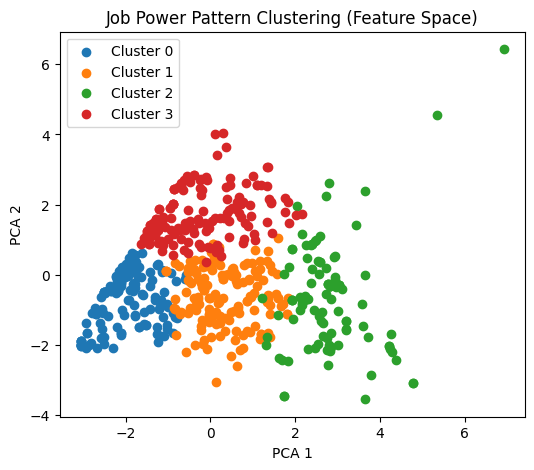

In [47]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,5))
for k in np.unique(labels):
    plt.scatter(X_pca[labels==k,0], X_pca[labels==k,1], label=f"Cluster {k}")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
plt.title("Job Power Pattern Clustering (Feature Space)")
plt.legend()
plt.show()

In [50]:

job_level_df["Cluster"] = labels
summary = job_level_df.groupby("Cluster").mean().round(2)
print("=== Cluster Feature Summary ===")
print(summary)

=== Cluster Feature Summary ===
             job_id  duration_sec  power_mean  power_std      max      min  \
Cluster                                                                      
0        2022798.53       2361.83      723.23      23.78   748.34   679.58   
1        2053319.00      18937.40      950.98     131.13  1146.72   699.62   
2        2018123.60      91729.91     1211.57     174.03  1458.69   618.46   
3        2044281.90       4380.34     1195.28      40.45  1241.98  1100.54   

          range  skew_p  kurt_p  
Cluster                          
0         68.76   -0.40    0.99  
1        447.09   -0.26    1.65  
2        840.23   -1.70   13.29  
3        141.44   -0.62    2.15  


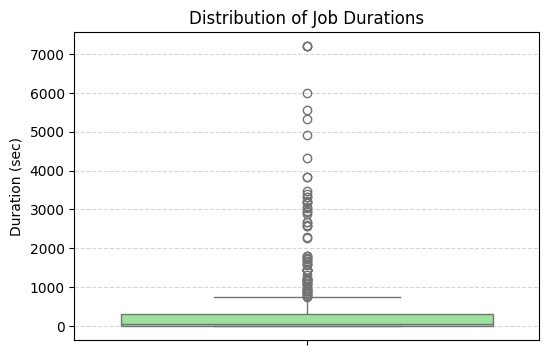

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(y=job_level_df['duration_min'], color='lightgreen')
plt.ylabel('Duration (min)')
plt.title('Distribution of Job Durations')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

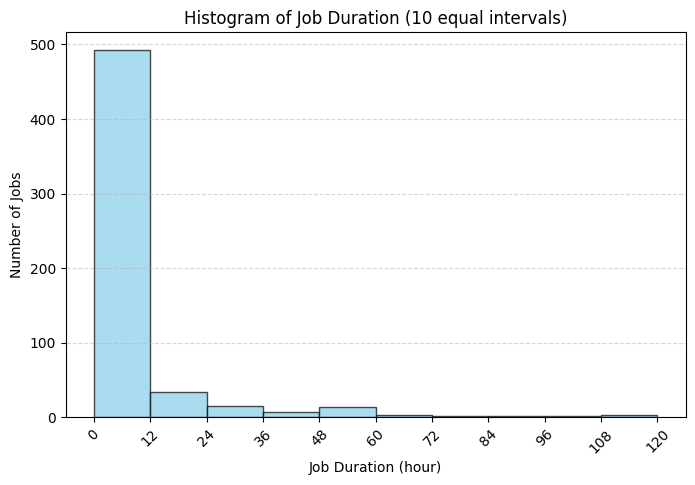

In [43]:
job_level_df['duration_hour'] = job_level_df['duration_min'] / 60

durations = job_level_df['duration_hour']

# === 1️⃣ 计算10等分区间 ===
bins = np.linspace(durations.min(), durations.max(), 11)  # 10等分 => 11个边界

# === 2️⃣ 绘制直方图 ===
plt.figure(figsize=(8,5))
plt.hist(durations, bins=bins, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Job Duration (hour)')
plt.ylabel('Number of Jobs')
plt.title('Histogram of Job Duration (10 equal intervals)')
plt.xticks(bins, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

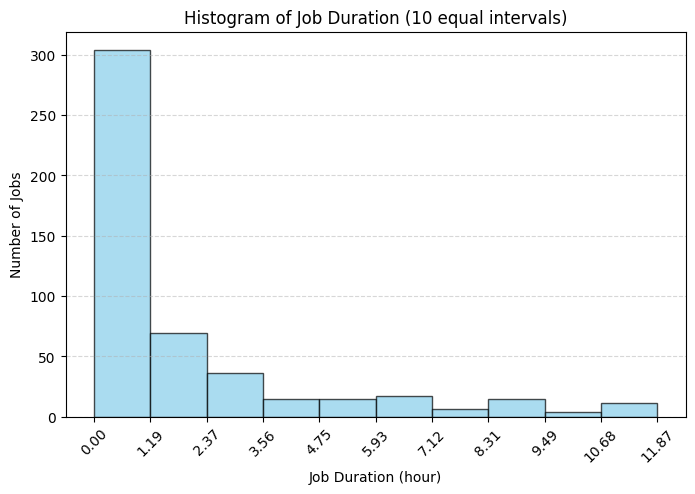

In [44]:
durations = job_level_df[job_level_df['duration_hour']<12]['duration_hour']

# === 1️⃣ 计算10等分区间 ===
bins = np.linspace(durations.min(), durations.max(), 11)  # 10等分 => 11个边界

# === 2️⃣ 绘制直方图 ===
plt.figure(figsize=(8,5))
plt.hist(durations, bins=bins, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Job Duration (hour)')
plt.ylabel('Number of Jobs')
plt.title('Histogram of Job Duration (10 equal intervals)')
plt.xticks(bins, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [39]:
job_level_df[job_level_df['duration_min'] > 1000].shape

(62, 8)

In [12]:
df.to_csv("../processed_data/surf_metrics.csv", index=False)

分析作业数据

In [51]:
job_df = pq.read_table("../ori_data/job_r28n4.parquet")
job_df = job_df.to_pandas(ignore_metadata=True)

In [52]:
job_df.head(10)

,id,submit_date,start_date,end_date,node,nodetypes,numnodes,numcores,state
0,560,2022-01-02 02:56:18,2022-01-02 02:56:19,2022-01-02 02:59:12,r28n4,gpu_titanrtx_short,1,24,COMPLETED
1,655,2022-01-02 11:50:52,2022-01-02 11:50:53,2022-01-02 13:28:49,r28n4,gpu_titanrtx_shared,1,6,COMPLETED
2,656,2022-01-02 11:51:06,2022-01-02 11:51:06,2022-01-02 13:28:28,r28n4,gpu_titanrtx_shared,1,6,COMPLETED
3,657,2022-01-02 11:51:11,2022-01-02 11:51:11,2022-01-02 13:28:49,r28n4,gpu_titanrtx_shared,1,6,COMPLETED
4,658,2022-01-02 11:51:14,2022-01-02 11:51:15,2022-01-02 13:28:28,r28n4,gpu_titanrtx_shared,1,6,COMPLETED
5,8733,2022-01-02 14:31:01,2022-01-02 14:31:01,2022-01-06 23:57:16,r28n4,gpu_titanrtx,1,24,COMPLETED
6,9362,2022-01-07 11:29:10,2022-01-07 11:29:11,2022-01-07 11:33:49,r28n4,gpu_titanrtx,1,24,COMPLETED
7,13684,2022-01-07 11:48:09,2022-01-07 11:48:09,2022-01-09 05:30:38,r28n4,gpu_titanrtx,1,24,FAILED
8,17403,2022-01-09 12:22:32,2022-01-09 12:22:33,2022-01-09 17:07:56,r28n4,gpu_titanrtx_shared,1,3,COMPLETED
9,17404,2022-01-09 12:22:32,2022-01-09 12:22:33,2022-01-09 17:18:40,r28n4,gpu_titanrtx_shared,1,3,COMPLETED


In [53]:
job_df['submit_date'] = pd.to_datetime(job_df['submit_date'])
job_df['start_date'] = pd.to_datetime(job_df['start_date'])
job_df['end_date'] = pd.to_datetime(job_df['end_date'])

In [18]:
job_df['nodetypes'].unique()

array(['gpu_titanrtx_short', 'gpu_titanrtx_shared', 'gpu_titanrtx',
       'gpu_titanrtx_shared_course'], dtype=object)

由于numnodes都为1，可以删除此列属性

In [54]:
job_df = job_df.drop('numnodes', axis=1)

In [55]:
job_df.shape

(4148, 8)

In [56]:
len(job_df['id'].unique())

4148

In [57]:
job_df['state'].unique()

array(['COMPLETED', 'FAILED', 'CANCELLED', 'TIMEOUT', 'OUT_OF_MEMORY',
       'NODE_FAIL'], dtype=object)

<Axes: title={'center': 'Daily Job Submissions'}, xlabel='submit_date'>

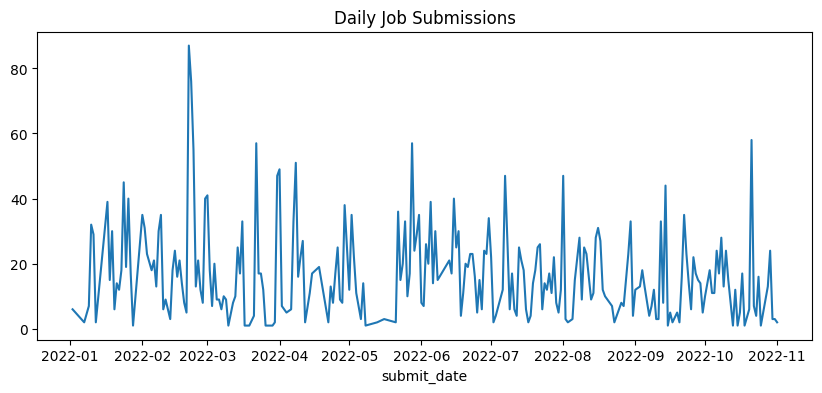

In [30]:
job_df['submit_date'] = job_df['submit_date'].dt.date
daily_jobs = job_df.groupby('submit_date').size()

daily_jobs.plot(kind='line', figsize=(10,4), title='Daily Job Submissions')

Text(0.5, 1.0, 'Hourly Job Submission Distribution')

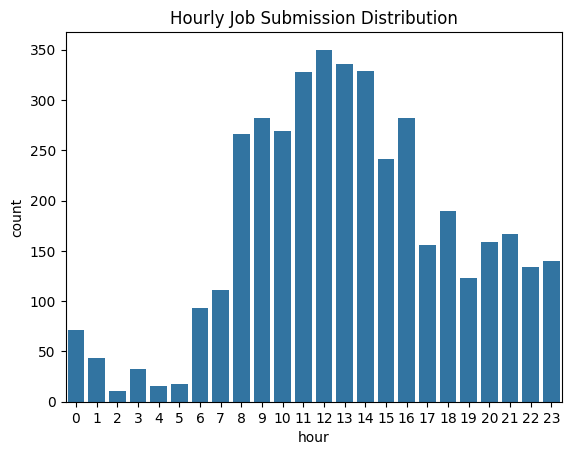

In [42]:
job_df['hour'] = job_df['submit_date'].dt.hour
sns.countplot(x='hour', data=job_df)
plt.title("Hourly Job Submission Distribution")

Text(0.5, 1.0, 'Weekly Job Submission Pattern')

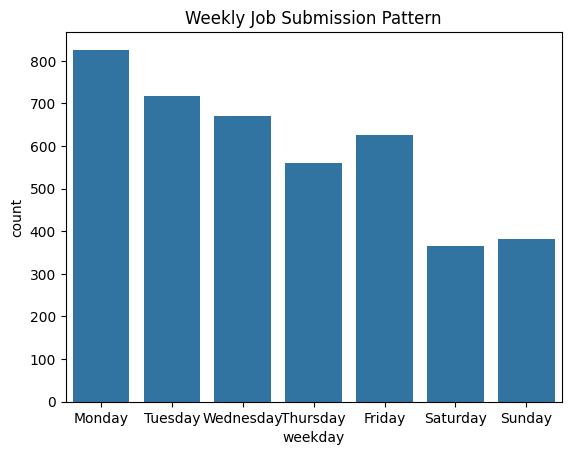

In [43]:
job_df['weekday'] = job_df['submit_date'].dt.day_name()
sns.countplot(x='weekday', data=job_df,
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Weekly Job Submission Pattern")

几乎没有自相关性，滞后性数值很弱。

卡时间和metric联合分析。metric时间为2022-08-25：2022-10-17 08:00:00

In [70]:
mask = (job_df['submit_date'] >= "2022-08-20 00:00:00") & (job_df['end_date'] <= "2022-10-17 08:00:00")
share_job = job_df[mask].copy()

In [60]:
share_job.head()

,id,submit_date,start_date,end_date,node,nodetypes,numcores,state
3352,1919687,2022-08-22 10:57:36,2022-08-22 10:57:37,2022-08-26 15:03:05,r28n4,gpu_titanrtx_shared,10,COMPLETED
3353,1893318,2022-08-22 13:44:16,2022-08-22 13:44:18,2022-08-22 13:44:28,r28n4,gpu_titanrtx_shared,6,FAILED
3354,1893319,2022-08-22 13:45:00,2022-08-22 13:45:03,2022-08-22 13:45:31,r28n4,gpu_titanrtx_shared,6,FAILED
3355,1893320,2022-08-22 13:46:42,2022-08-22 13:46:43,2022-08-22 13:47:10,r28n4,gpu_titanrtx_shared,6,FAILED
3356,1893328,2022-08-22 13:54:02,2022-08-22 13:54:03,2022-08-22 13:54:31,r28n4,gpu_titanrtx_shared,6,FAILED


In [71]:
share_job['delay_minutes'] = (share_job['start_date'] - share_job['submit_date']).dt.total_seconds() / 60

In [80]:
bins = [0, 5, 30, 60, 120, 360, 1440]
labels = ['0-5min', '5-30min', '30-60min', '1-2h', '2-6h', '6-24h']

share_job['delay_category'] = pd.cut(share_job['delay_minutes'], bins=bins, labels=labels, right=False)

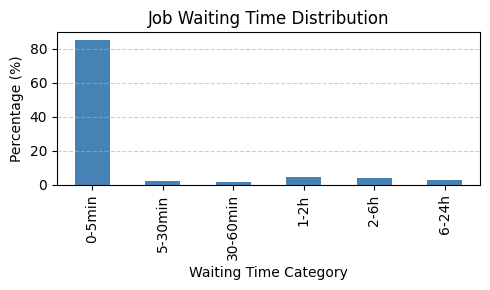

In [82]:
delay_stats = share_job['delay_category'].value_counts(normalize=False).sort_index()
delay_ratio = share_job['delay_category'].value_counts(normalize=True).sort_index() * 100

# 合并为 DataFrame 方便展示
delay_summary = pd.DataFrame({
    'count': delay_stats,
    'percentage (%)': delay_ratio.round(2)
})

plt.figure(figsize=(5, 3))
delay_summary['percentage (%)'].plot(kind='bar', color='steelblue')
plt.title('Job Waiting Time Distribution')
plt.xlabel('Waiting Time Category')
plt.ylabel('Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [79]:
delay_summary

,count,percentage (%)
delay_category,,
0-5min,546,85.31
5-30min,14,2.19
30-60min,9,1.41
1-2h,27,4.22
2-6h,25,3.91
6-24h,19,2.97
24-28h,0,0.00
>2d,0,0.00


In [12]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [ ]:
df['job_count'] = 0
for _, job in job_df.iterrows():
    mask = (df['timestamp'] >= job['start_date']) & (df['timestamp'] <= job['end_date'])
    df.loc[mask, 'job_count'] += 1

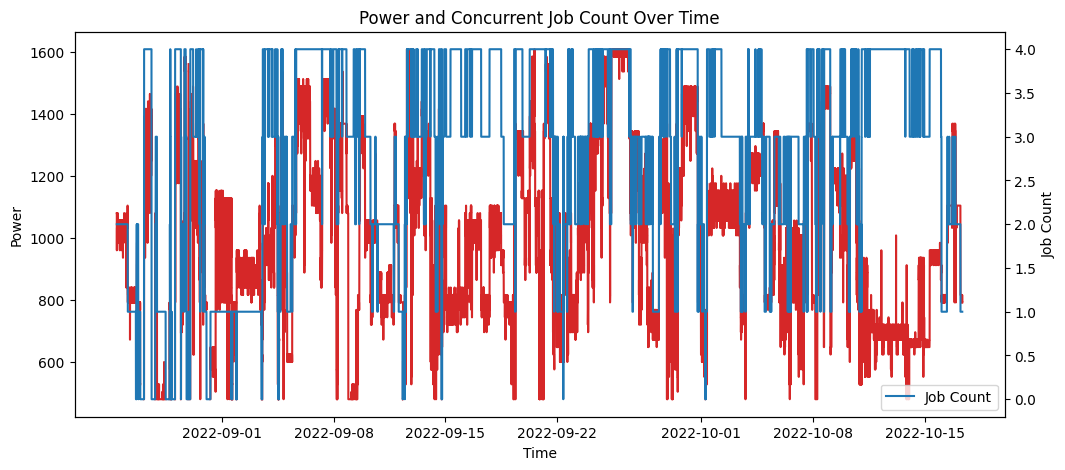

In [19]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(df['timestamp'], df['node_power_usage'], label='Power (W)', color='tab:red')
ax2 = ax1.twinx()
ax2.plot(df['timestamp'], df['job_count'], label='Job Count', color='tab:blue')
ax1.set_xlabel('Time')
ax1.set_ylabel('Power')
ax2.set_ylabel('Job Count')
plt.title('Power and Concurrent Job Count Over Time')
plt.legend()
plt.show()

后面一部分高作业数量，但是能耗并不高。

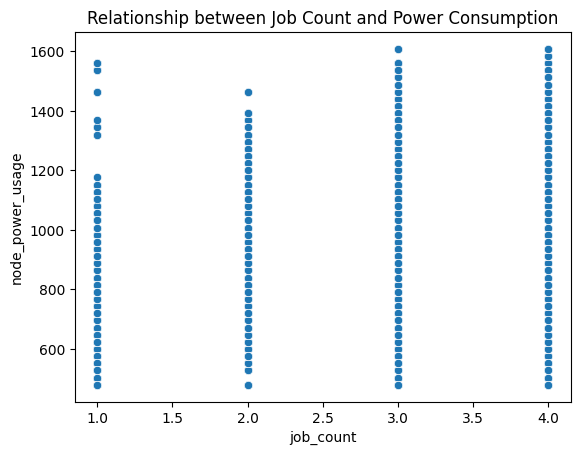

In [20]:
import seaborn as sns

sns.scatterplot(x='job_count', y='node_power_usage', data=df)
plt.title("Relationship between Job Count and Power Consumption")
plt.show()

In [22]:
corr = df[['job_count', 'node_power_usage']].corr()
print(corr)

                  job_count  node_power_usage
job_count          1.000000          0.489009
node_power_usage   0.489009          1.000000


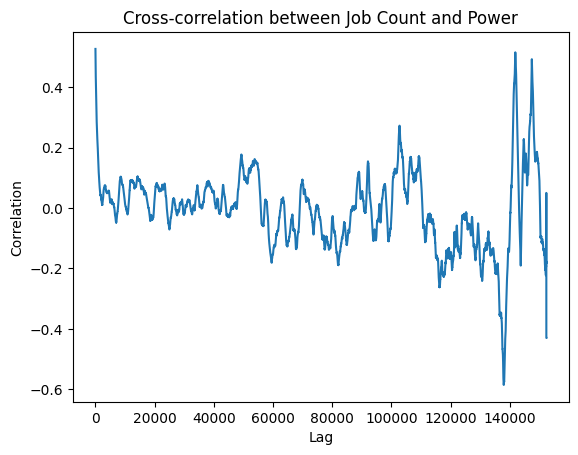

In [26]:
from statsmodels.tsa.stattools import ccf
import numpy as np

cross_corr = ccf(df['job_count'], df['node_power_usage'])
plt.plot(range(len(cross_corr)), cross_corr)
plt.title("Cross-correlation between Job Count and Power")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.show()

作业数量不是功耗的主驱动因素。需要更细粒度，从作业资源需求，分析功耗。

In [83]:
share_job.head()

,id,submit_date,start_date,end_date,node,nodetypes,numcores,state,delay_minutes,delay_category
3352,1919687,2022-08-22 10:57:36,2022-08-22 10:57:37,2022-08-26 15:03:05,r28n4,gpu_titanrtx_shared,10,COMPLETED,0.016667,0-5min
3353,1893318,2022-08-22 13:44:16,2022-08-22 13:44:18,2022-08-22 13:44:28,r28n4,gpu_titanrtx_shared,6,FAILED,0.033333,0-5min
3354,1893319,2022-08-22 13:45:00,2022-08-22 13:45:03,2022-08-22 13:45:31,r28n4,gpu_titanrtx_shared,6,FAILED,0.050000,0-5min
3355,1893320,2022-08-22 13:46:42,2022-08-22 13:46:43,2022-08-22 13:47:10,r28n4,gpu_titanrtx_shared,6,FAILED,0.016667,0-5min
3356,1893328,2022-08-22 13:54:02,2022-08-22 13:54:03,2022-08-22 13:54:31,r28n4,gpu_titanrtx_shared,6,FAILED,0.016667,0-5min


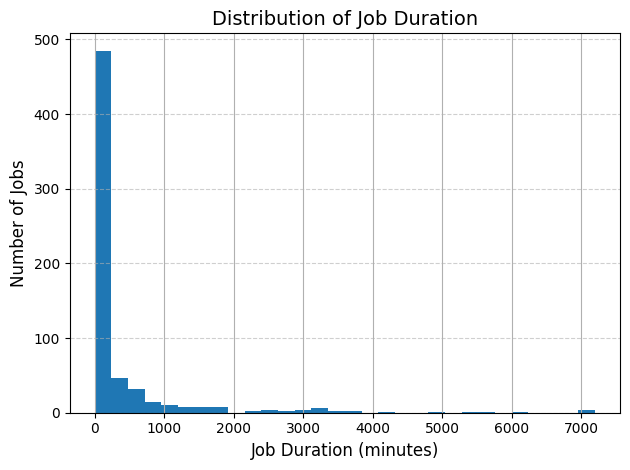

In [86]:
share_job['duration_m'] = (share_job['end_date'] - share_job['start_date']).dt.total_seconds() / 60
share_job['duration_m'].hist(bins=30)
plt.title('Distribution of Job Duration', fontsize=14)
plt.xlabel('Job Duration (minutes)', fontsize=12)   # X轴：持续时间（分钟）
plt.ylabel('Number of Jobs', fontsize=12)           # Y轴：作业个数
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

构造作业级别的功耗时序变化
其中，以作业为单位，每个作业的功耗变化情况,
如若多个作业同时发生，则根据作业的所占核数加权平均功率。

In [87]:
df['window_start'] = df.index
df['window_end'] = df['window_start'] + pd.Timedelta(seconds=30)

from collections import defaultdict
job_power_series = defaultdict(list)

for _, row in df.iterrows():
    active_jobs = share_job[
        (share_job['start_date'] < row['window_end']) &
        (share_job['end_date'] > row['window_start'])
    ]
    if len(active_jobs) > 0:
        total_cores = active_jobs['numcores'].sum()
        for _, job in active_jobs.iterrows():
            share = row['node_power_usage'] * (job['numcores'] / total_cores)
            job_power_series[job['id']].append((row['window_start'], share))

In [88]:
len(job_power_series)

633

In [89]:
job_power_series.keys()

dict_keys([1919687, 1917196, 1920248, 1920360, 1920257, 1920366, 1920424, 1920467, 1920527, 1920586, 1921211, 1921212, 1921213, 1921214, 1921638, 1921639, 1922812, 1923110, 1923362, 1923403, 1923447, 1923457, 1923462, 1923642, 1923652, 1923653, 1923654, 1923655, 1923703, 1923708, 1923719, 1923729, 1924969, 1924972, 1924971, 1924970, 1925221, 1925037, 1925038, 1925109, 1925112, 1925118, 1925125, 1925126, 1925600, 1925364, 1925607, 1925999, 1925859, 1925902, 1926078, 1926079, 1926080, 1926219, 1926323, 1927670, 1928801, 1928852, 1929233, 1928315, 1928318, 1928652, 1928653, 1928662, 1928663, 1928676, 1928741, 1928756, 1928774, 1928819, 1928895, 1928896, 1929315, 1929316, 1929317, 1929360, 1929379, 1929380, 1929393, 1929394, 1929408, 1929409, 1929570, 1929571, 1929587, 1929706, 1929711, 1929784, 1930039, 1930656, 1931165, 1933496, 1933626, 1933844, 1934066, 1934084, 1934085, 1934087, 1934181, 1934182, 1934188, 1934190, 1934191, 1936394, 1936653, 1936658, 1936686, 1936728, 1936729, 1936698,

In [92]:
import pickle

# 保存到文件
with open('../processed_data/surf_job_power.pkl', 'wb') as f:
    pickle.dump(job_power_series, f)

横坐标表示时间，纵坐标表示作业，缺失部分为空缺值。
这样组织的数据便于切分

In [131]:
job_power_trace = df['node_power_usage'].copy().to_frame()

In [132]:
for job, pow in job_power_series.items():
    _time, _power = zip(*pow)
    job_power_trace[str(job)] = None
    job_power_trace.loc[list(_time), str(job)] = _power

/tmp/ipykernel_574461/128100476.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  job_power_trace[str(job)] = None
/tmp/ipykernel_574461/128100476.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  job_power_trace[str(job)] = None
/tmp/ipykernel_574461/128100476.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe =

In [134]:
job_power_trace.head(3)

,node_power_usage,1919687,1917196,1920248,1920360,1920257,1920366,1920424,1920467,1920527,...,2170092,2170185,2170190,2172384,2175949,2177930,2176480,2176832,2177523,2177764
timestamp,,,,,,,,,,,,,,,,,,,,,
2022-08-25 10:27:00,1080.0,675.0,405.0,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2022-08-25 10:27:30,1080.0,675.0,405.0,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2022-08-25 10:28:00,1080.0,675.0,405.0,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [135]:
job_power_trace = job_power_trace.drop('node_power_usage', axis=1)

In [136]:
job_power_trace.shape

(152347, 633)

In [137]:
job_power_trace.to_csv('../processed_data/surf_job_trace_power.csv', index=True)

In [114]:
job_power_trace.head(2)

,node_power_usage,1919687
timestamp,,
2022-08-25 10:27:00,1080.0,None
2022-08-25 10:27:30,1080.0,None


In [ ]:
'''
job_power: {"id": ID,
"power_trace": [timestamp, power],
"submit_date" timestamp,  # 用于对齐历史窗口内的作业
"start_date": timestamp,
"end_date": timestamp,
"numcore": xxx,
"nodetypes": xxx.
}
'''

job_power_trace = {}

for key, item in job_power_series.items():
    job_power_trace['id']

In [ ]:
from multiprocessing import Pool
from itertools import combinations
from fastdtw import fastdtw
from tqdm import tqdm

In [96]:
polished_job_power = {}

for job, power in job_power_series.items():
    if len(power) < 3:
        continue
    if len(power) > 1000:
        power = power[::10]
    polished_job_power[job] = power

In [107]:
### DTW计算太慢了，

# job_ids = list(polished_job_power.keys())
# seqs_norm = []

# for job_id in job_ids:
#     seq = np.array([p for _, p in polished_job_power[job_id]])
#     # # mean-std 归一化
#     # seq_norm = (seq - seq.mean()) / seq.std()
#     seqs_norm.append(seq)

# # === 计算 DTW 距离矩阵 ===
# n = len(job_ids)
# dtw_matrix = np.zeros((n, n))

# for i in tqdm(range(n), desc="Computing DTW"):
#     for j in range(i+1, n):
#         # dist = dtw.distance(seqs_norm[i], seqs_norm[j])
#         try:
#             dist, _ = fastdtw(seqs_norm[i], seqs_norm[j], radius=10)
#         except Exception as e:
#             print(seqs_norm[i])
#             print(seqs_norm[j])
#             print(j)
#         dist, _ = fastdtw(seqs_norm[i], seqs_norm[j], radius=10)
#         dtw_matrix[i, j] = dist
#         dtw_matrix[j, i] = dist

如果相似的比较多，可以直接匹配，然后当作未来窗口的预测值。

In [108]:
polished_job_power.keys()

dict_keys([1919687, 1917196, 1920248, 1920360, 1920257, 1920366, 1920424, 1920467, 1920527, 1920586, 1921211, 1921212, 1921213, 1921214, 1921638, 1921639, 1922812, 1923362, 1923447, 1923457, 1923462, 1923642, 1923719, 1923729, 1924969, 1924972, 1924971, 1924970, 1925221, 1925037, 1925109, 1925112, 1925600, 1925364, 1925607, 1925999, 1925859, 1926078, 1926079, 1926080, 1926323, 1927670, 1928801, 1928852, 1929233, 1928318, 1928653, 1928662, 1928663, 1928676, 1928741, 1928756, 1928774, 1928819, 1928895, 1928896, 1929315, 1929316, 1929317, 1929360, 1929379, 1929380, 1929393, 1929394, 1929408, 1929409, 1929570, 1929571, 1929587, 1929706, 1929711, 1929784, 1930039, 1930656, 1931165, 1933496, 1933626, 1933844, 1934066, 1934181, 1934182, 1934188, 1934190, 1934191, 1936394, 1936653, 1936686, 1936728, 1936729, 1937241, 1937288, 1937292, 1936896, 1936920, 1936932, 1937044, 1937111, 1937261, 1937333, 1937304, 1937325, 1937339, 1937340, 1937350, 1937351, 1937861, 1937524, 1937553, 1937554, 1937694,

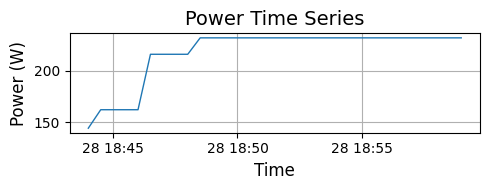

In [95]:
data = job_power_series[1923462]
df = pd.DataFrame(data, columns=['time', 'power'])
df['time'] = pd.to_datetime(df['time'])

# 绘图
plt.figure(figsize=(5, 2))
plt.plot(df['time'], df['power'], linestyle='-', linewidth=1)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Power (W)', fontsize=12)
plt.title('Power Time Series', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

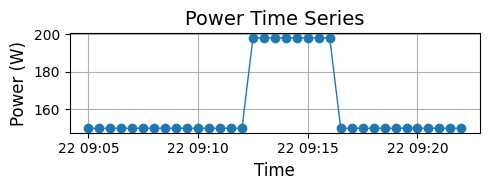

In [ ]:
data = polished_job_power[2048822]
df = pd.DataFrame(data, columns=['time', 'power'])
df['time'] = pd.to_datetime(df['time'])

# 绘图
plt.figure(figsize=(5, 2))
plt.plot(df['time'], df['power'], marker='o', linestyle='-', linewidth=1)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Power (W)', fontsize=12)
plt.title('Power Time Series', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

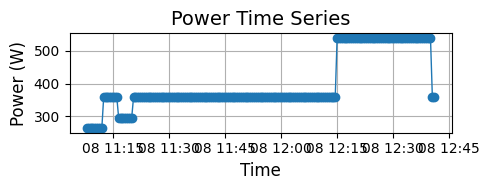

In [ ]:
data = polished_job_power[2135728]
df = pd.DataFrame(data, columns=['time', 'power'])
df['time'] = pd.to_datetime(df['time'])

# 绘图
plt.figure(figsize=(5, 2))
plt.plot(df['time'], df['power'], linestyle='-', linewidth=1)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Power (W)', fontsize=12)
plt.title('Power Time Series', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

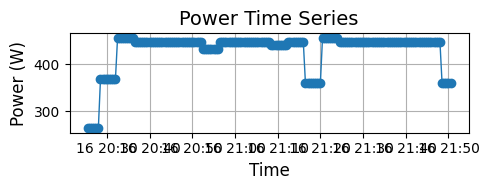

In [118]:
data = polished_job_power[2177764]
df = pd.DataFrame(data, columns=['time', 'power'])
df['time'] = pd.to_datetime(df['time'])

# 绘图
plt.figure(figsize=(5, 2))
plt.plot(df['time'], df['power'], marker='o', linestyle='-', linewidth=1)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Power (W)', fontsize=12)
plt.title('Power Time Series', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()